- 1. data cleaning
- 2. EDA
- 3. Feature eng


In [156]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

In [157]:
df=pd.read_csv('https://raw.githubusercontent.com/krishnaik06/playstore-Dataset/main/googleplaystore.csv')
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [158]:
df.shape

(10841, 13)

In [159]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [160]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [161]:
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

Observation : The dataset has null values at rating,type, last updated,curr ver,android ver

## Data Cleaning

In [162]:
# 

df['Reviews'].unique()

array(['159', '967', '87510', ..., '603', '1195', '398307'], dtype=object)

In [163]:
df['Reviews'].str.isnumeric().sum()

np.int64(10840)

In [164]:
df[~df['Reviews'].str.isnumeric()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [165]:
# df.Reviews.astype(int)

In [166]:
df_copy = df.copy()

In [167]:
df_copy = df_copy.drop(df_copy.index[10472])

In [168]:
df_copy.Reviews =df_copy.Reviews.astype(int)

In [169]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            10840 non-null  object 
 5   Installs        10840 non-null  object 
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 1.2+ MB


In [170]:
# df_copy['Size'] = df_copy['Size'].str.split('M').str[0]

#19M = 19000K


df_copy['Size'] = df_copy['Size'].str.replace('M','000')
df_copy['Size'] = df_copy['Size'].str.replace('k','')

df_copy['Size'] = df_copy['Size'].replace('Varies with device',np.nan)

df_copy['Size(k)'] = df_copy['Size'].astype(float)




In [171]:
df_copy['Size'].isnull().sum()


np.int64(1695)

In [172]:
df_copy['Size'].unique()

array(['19000', '14000', '8.7000', '25000', '2.8000', '5.6000', '29000',
       '33000', '3.1000', '28000', '12000', '20000', '21000', '37000',
       '2.7000', '5.5000', '17000', '39000', '31000', '4.2000', '7.0000',
       '23000', '6.0000', '6.1000', '4.6000', '9.2000', '5.2000', '11000',
       '24000', nan, '9.4000', '15000', '10000', '1.2000', '26000',
       '8.0000', '7.9000', '56000', '57000', '35000', '54000', '201',
       '3.6000', '5.7000', '8.6000', '2.4000', '27000', '2.5000', '16000',
       '3.4000', '8.9000', '3.9000', '2.9000', '38000', '32000', '5.4000',
       '18000', '1.1000', '2.2000', '4.5000', '9.8000', '52000', '9.0000',
       '6.7000', '30000', '2.6000', '7.1000', '3.7000', '22000', '7.4000',
       '6.4000', '3.2000', '8.2000', '9.9000', '4.9000', '9.5000',
       '5.0000', '5.9000', '13000', '73000', '6.8000', '3.5000', '4.0000',
       '2.3000', '7.2000', '2.1000', '42000', '7.3000', '9.1000', '55000',
       '23', '6.5000', '1.5000', '7.5000', '51000', 

In [173]:
df_copy.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size(k)
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,19000.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,14000.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7000,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,8.7
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,25000.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8000,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,2.8


In [174]:
df.Installs.unique()



array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+', '0', 'Free'], dtype=object)

In [175]:
df.Price.unique()

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', 'Everyone', '$1.20', '$1.04'], dtype=object)

In [176]:
chars_to_remove = ['+', ',', '$']
cols_to_clean =['Installs', 'Price']

for item in  chars_to_remove:
    for cols in cols_to_clean:
        df_copy[cols] = df_copy[cols].str.replace(item,'')

df_copy.head(5)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size(k)
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000,10000,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,19000.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000,500000,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,14000.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7000,5000000,Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,8.7
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000,50000000,Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,25000.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8000,100000,Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,2.8


In [177]:
df_copy.Installs.unique()

array(['10000', '500000', '5000000', '50000000', '100000', '50000',
       '1000000', '10000000', '5000', '100000000', '1000000000', '1000',
       '500000000', '50', '100', '500', '10', '1', '5', '0'], dtype=object)

In [178]:
df_copy.Installs = df_copy.Installs.astype('int')
df_copy.Price = df_copy.Price.astype('float')


In [179]:
df_copy['Last Updated'].unique()

array(['January 7, 2018', 'January 15, 2018', 'August 1, 2018', ...,
       'January 20, 2014', 'February 16, 2014', 'March 23, 2014'],
      dtype=object)

In [180]:
df_copy["Last Updated"] = pd.to_datetime(df_copy['Last Updated'])

df_copy


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size(k)
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,19000.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,14000.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7000,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,8.7
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,25000.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8000,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,2.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53000,5000,Free,0.0,Everyone,Education,2017-07-25,1.48,4.1 and up,53000.0
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6000,100,Free,0.0,Everyone,Education,2018-07-06,1.0,4.1 and up,3.6
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5000,1000,Free,0.0,Everyone,Medical,2017-01-20,1.0,2.2 and up,9.5
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,NaN,1000,Free,0.0,Mature 17+,Books & Reference,2015-01-19,Varies with device,Varies with device,NaN


In [181]:
df_copy["day"] = df_copy['Last Updated'].dt.day
df_copy["month"] = df_copy['Last Updated'].dt.month
df_copy["year"] = df_copy['Last Updated'].dt.year

In [182]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10840 non-null  object        
 1   Category        10840 non-null  object        
 2   Rating          9366 non-null   float64       
 3   Reviews         10840 non-null  int64         
 4   Size            9145 non-null   object        
 5   Installs        10840 non-null  int64         
 6   Type            10839 non-null  object        
 7   Price           10840 non-null  float64       
 8   Content Rating  10840 non-null  object        
 9   Genres          10840 non-null  object        
 10  Last Updated    10840 non-null  datetime64[ns]
 11  Current Ver     10832 non-null  object        
 12  Android Ver     10838 non-null  object        
 13  Size(k)         9145 non-null   float64       
 14  day             10840 non-null  int32         
 15  month  

In [183]:
df['Category'].unique()

array(['ART_AND_DESIGN', 'AUTO_AND_VEHICLES', 'BEAUTY',
       'BOOKS_AND_REFERENCE', 'BUSINESS', 'COMICS', 'COMMUNICATION',
       'DATING', 'EDUCATION', 'ENTERTAINMENT', 'EVENTS', 'FINANCE',
       'FOOD_AND_DRINK', 'HEALTH_AND_FITNESS', 'HOUSE_AND_HOME',
       'LIBRARIES_AND_DEMO', 'LIFESTYLE', 'GAME', 'FAMILY', 'MEDICAL',
       'SOCIAL', 'SHOPPING', 'PHOTOGRAPHY', 'SPORTS', 'TRAVEL_AND_LOCAL',
       'TOOLS', 'PERSONALIZATION', 'PRODUCTIVITY', 'PARENTING', 'WEATHER',
       'VIDEO_PLAYERS', 'NEWS_AND_MAGAZINES', 'MAPS_AND_NAVIGATION',
       '1.9'], dtype=object)

In [184]:
df_copy.to_csv('google_playstore_cleaned_data.csv')

# EDA


In [185]:
data = pd.read_csv("google_playstore_cleaned_data.csv")

In [186]:
data.duplicated('App').sum()

np.int64(1181)

In [187]:
data[data.duplicated('App')]

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size(k),day,month,year
229,229,Quick PDF Scanner + OCR FREE,BUSINESS,4.2,80805,NaN,5000000,Free,0.0,Everyone,Business,2018-02-26,Varies with device,4.0.3 and up,NaN,26,2,2018
236,236,Box,BUSINESS,4.2,159872,NaN,10000000,Free,0.0,Everyone,Business,2018-07-31,Varies with device,Varies with device,NaN,31,7,2018
239,239,Google My Business,BUSINESS,4.4,70991,NaN,5000000,Free,0.0,Everyone,Business,2018-07-24,2.19.0.204537701,4.4 and up,NaN,24,7,2018
256,256,ZOOM Cloud Meetings,BUSINESS,4.4,31614,37000.0,10000000,Free,0.0,Everyone,Business,2018-07-20,4.1.28165.0716,4.0 and up,37000.0,20,7,2018
261,261,join.me - Simple Meetings,BUSINESS,4.0,6989,NaN,1000000,Free,0.0,Everyone,Business,2018-07-16,4.3.0.508,4.4 and up,NaN,16,7,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10714,10715,FarmersOnly Dating,DATING,3.0,1145,1.4,100000,Free,0.0,Mature 17+,Dating,2016-02-25,2.2,4.0 and up,1.4,25,2,2016
10719,10720,Firefox Focus: The privacy browser,COMMUNICATION,4.4,36981,4.0,1000000,Free,0.0,Everyone,Communication,2018-07-06,5.2,5.0 and up,4.0,6,7,2018
10729,10730,FP Notebook,MEDICAL,4.5,410,60000.0,50000,Free,0.0,Everyone,Medical,2018-03-24,2.1.0.372,4.4 and up,60000.0,24,3,2018
10752,10753,Slickdeals: Coupons & Shopping,SHOPPING,4.5,33599,12000.0,1000000,Free,0.0,Everyone,Shopping,2018-07-30,3.9,4.4 and up,12000.0,30,7,2018


#### observation :  dataset has duplicate values

In [188]:
data = data.drop_duplicates(subset= ["App"], keep='first')

In [189]:
data.shape

(9659, 18)

In [190]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9659 entries, 0 to 10839
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   object 
 2   Category        9659 non-null   object 
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   int64  
 7   Type            9658 non-null   object 
 8   Price           9659 non-null   float64
 9   Content Rating  9659 non-null   object 
 10  Genres          9659 non-null   object 
 11  Last Updated    9659 non-null   object 
 12  Current Ver     9651 non-null   object 
 13  Android Ver     9657 non-null   object 
 14  Size(k)         8432 non-null   float64
 15  day             9659 non-null   int64  
 16  month           9659 non-null   int64  
 17  year            9659 non-null   int64

In [191]:
data.drop(['Unnamed: 0','Last Updated'],axis=1, inplace= True)

In [192]:
numeric_features = [feature for feature in data.columns if data[feature].dtype != 'O']

print('we have {} numerical features {}'.format(len(numeric_features),numeric_features))

we have 9 numerical features ['Rating', 'Reviews', 'Size', 'Installs', 'Price', 'Size(k)', 'day', 'month', 'year']


In [193]:
categorical_features = [feature for feature in data.columns if data[feature].dtype == 'O']

print('we have {} categorical features {}'.format(len(categorical_features),categorical_features))

we have 7 categorical features ['App', 'Category', 'Type', 'Content Rating', 'Genres', 'Current Ver', 'Android Ver']


In [194]:
# # numbers of count data on categorical columns

for col in categorical_features:
    print(data[col].value_counts())
    print('==========================================================')

App
iHoroscope - 2018 Daily Horoscope & Astrology         1
Photo Editor & Candy Camera & Grid & ScrapBook        1
Coloring book moana                                   1
U Launcher Lite – FREE Live Cool Themes, Hide Apps    1
Sketch - Draw & Paint                                 1
                                                     ..
Learn To Draw Kawaii Characters                       1
3D Color Pixel by Number - Sandbox Art Coloring       1
Mandala Coloring Book                                 1
Tattoo Name On My Photo Editor                        1
Name Art Photo Editor - Focus n Filters               1
Name: count, Length: 9659, dtype: int64
Category
FAMILY                 1832
GAME                    959
TOOLS                   827
BUSINESS                420
MEDICAL                 395
PERSONALIZATION         376
PRODUCTIVITY            374
LIFESTYLE               369
FINANCE                 345
SPORTS                  325
COMMUNICATION           315
HEALTH_AND_FITNESS     

In [195]:
# Proportion of count data on categorical columns

for col in categorical_features:
    print(data[col].value_counts(normalize= True) * 100) # normalize give the percentage value
    print('==========================================================')

App
iHoroscope - 2018 Daily Horoscope & Astrology         0.010353
Photo Editor & Candy Camera & Grid & ScrapBook        0.010353
Coloring book moana                                   0.010353
U Launcher Lite – FREE Live Cool Themes, Hide Apps    0.010353
Sketch - Draw & Paint                                 0.010353
                                                        ...   
Learn To Draw Kawaii Characters                       0.010353
3D Color Pixel by Number - Sandbox Art Coloring       0.010353
Mandala Coloring Book                                 0.010353
Tattoo Name On My Photo Editor                        0.010353
Name Art Photo Editor - Focus n Filters               0.010353
Name: proportion, Length: 9659, dtype: float64
Category
FAMILY                 18.966767
GAME                    9.928564
TOOLS                   8.561963
BUSINESS                4.348276
MEDICAL                 4.089450
PERSONALIZATION         3.892743
PRODUCTIVITY            3.872036
LIFESTYLE       

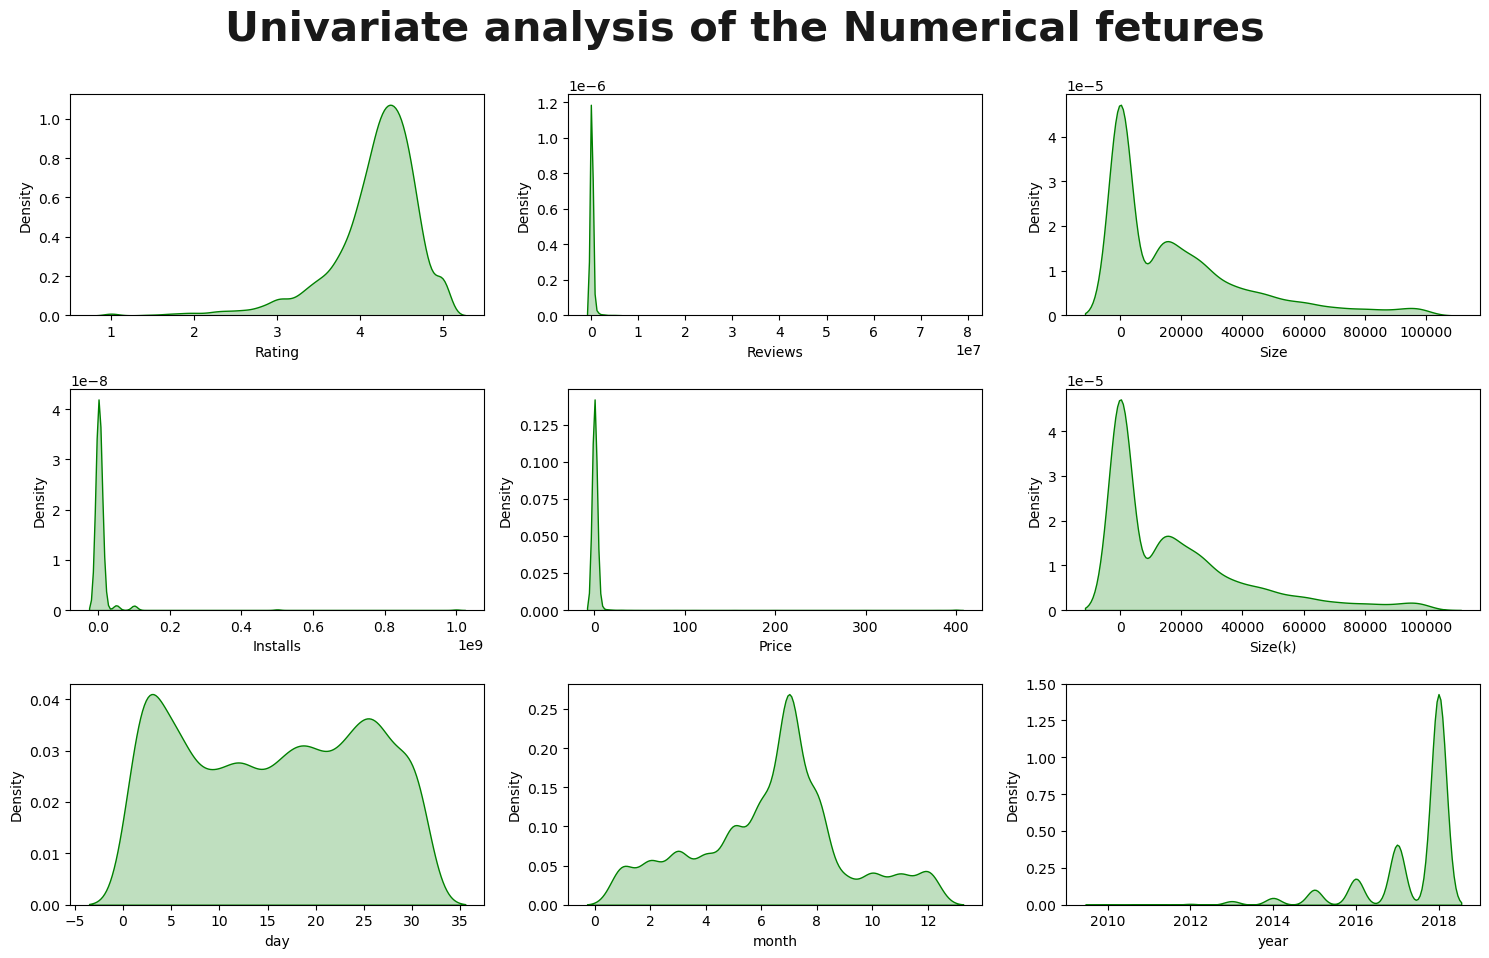

In [196]:
# proportion of count of numerical columns

# kde = kernal density estimator

plt.figure(figsize=(15,15))

plt.suptitle("Univariate analysis of the Numerical fetures", fontsize= 30,fontweight= 'bold',alpha=0.9,y=1.)

for i in range(0,len(numeric_features)):
    plt.subplot(5,3, i+1)
    sns.kdeplot(x = data[numeric_features[i]],shade = True, color ='g')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()



## observation

- Rating and Year is right skewed 
- Size, Reviews, Installs and Price is left Skewed

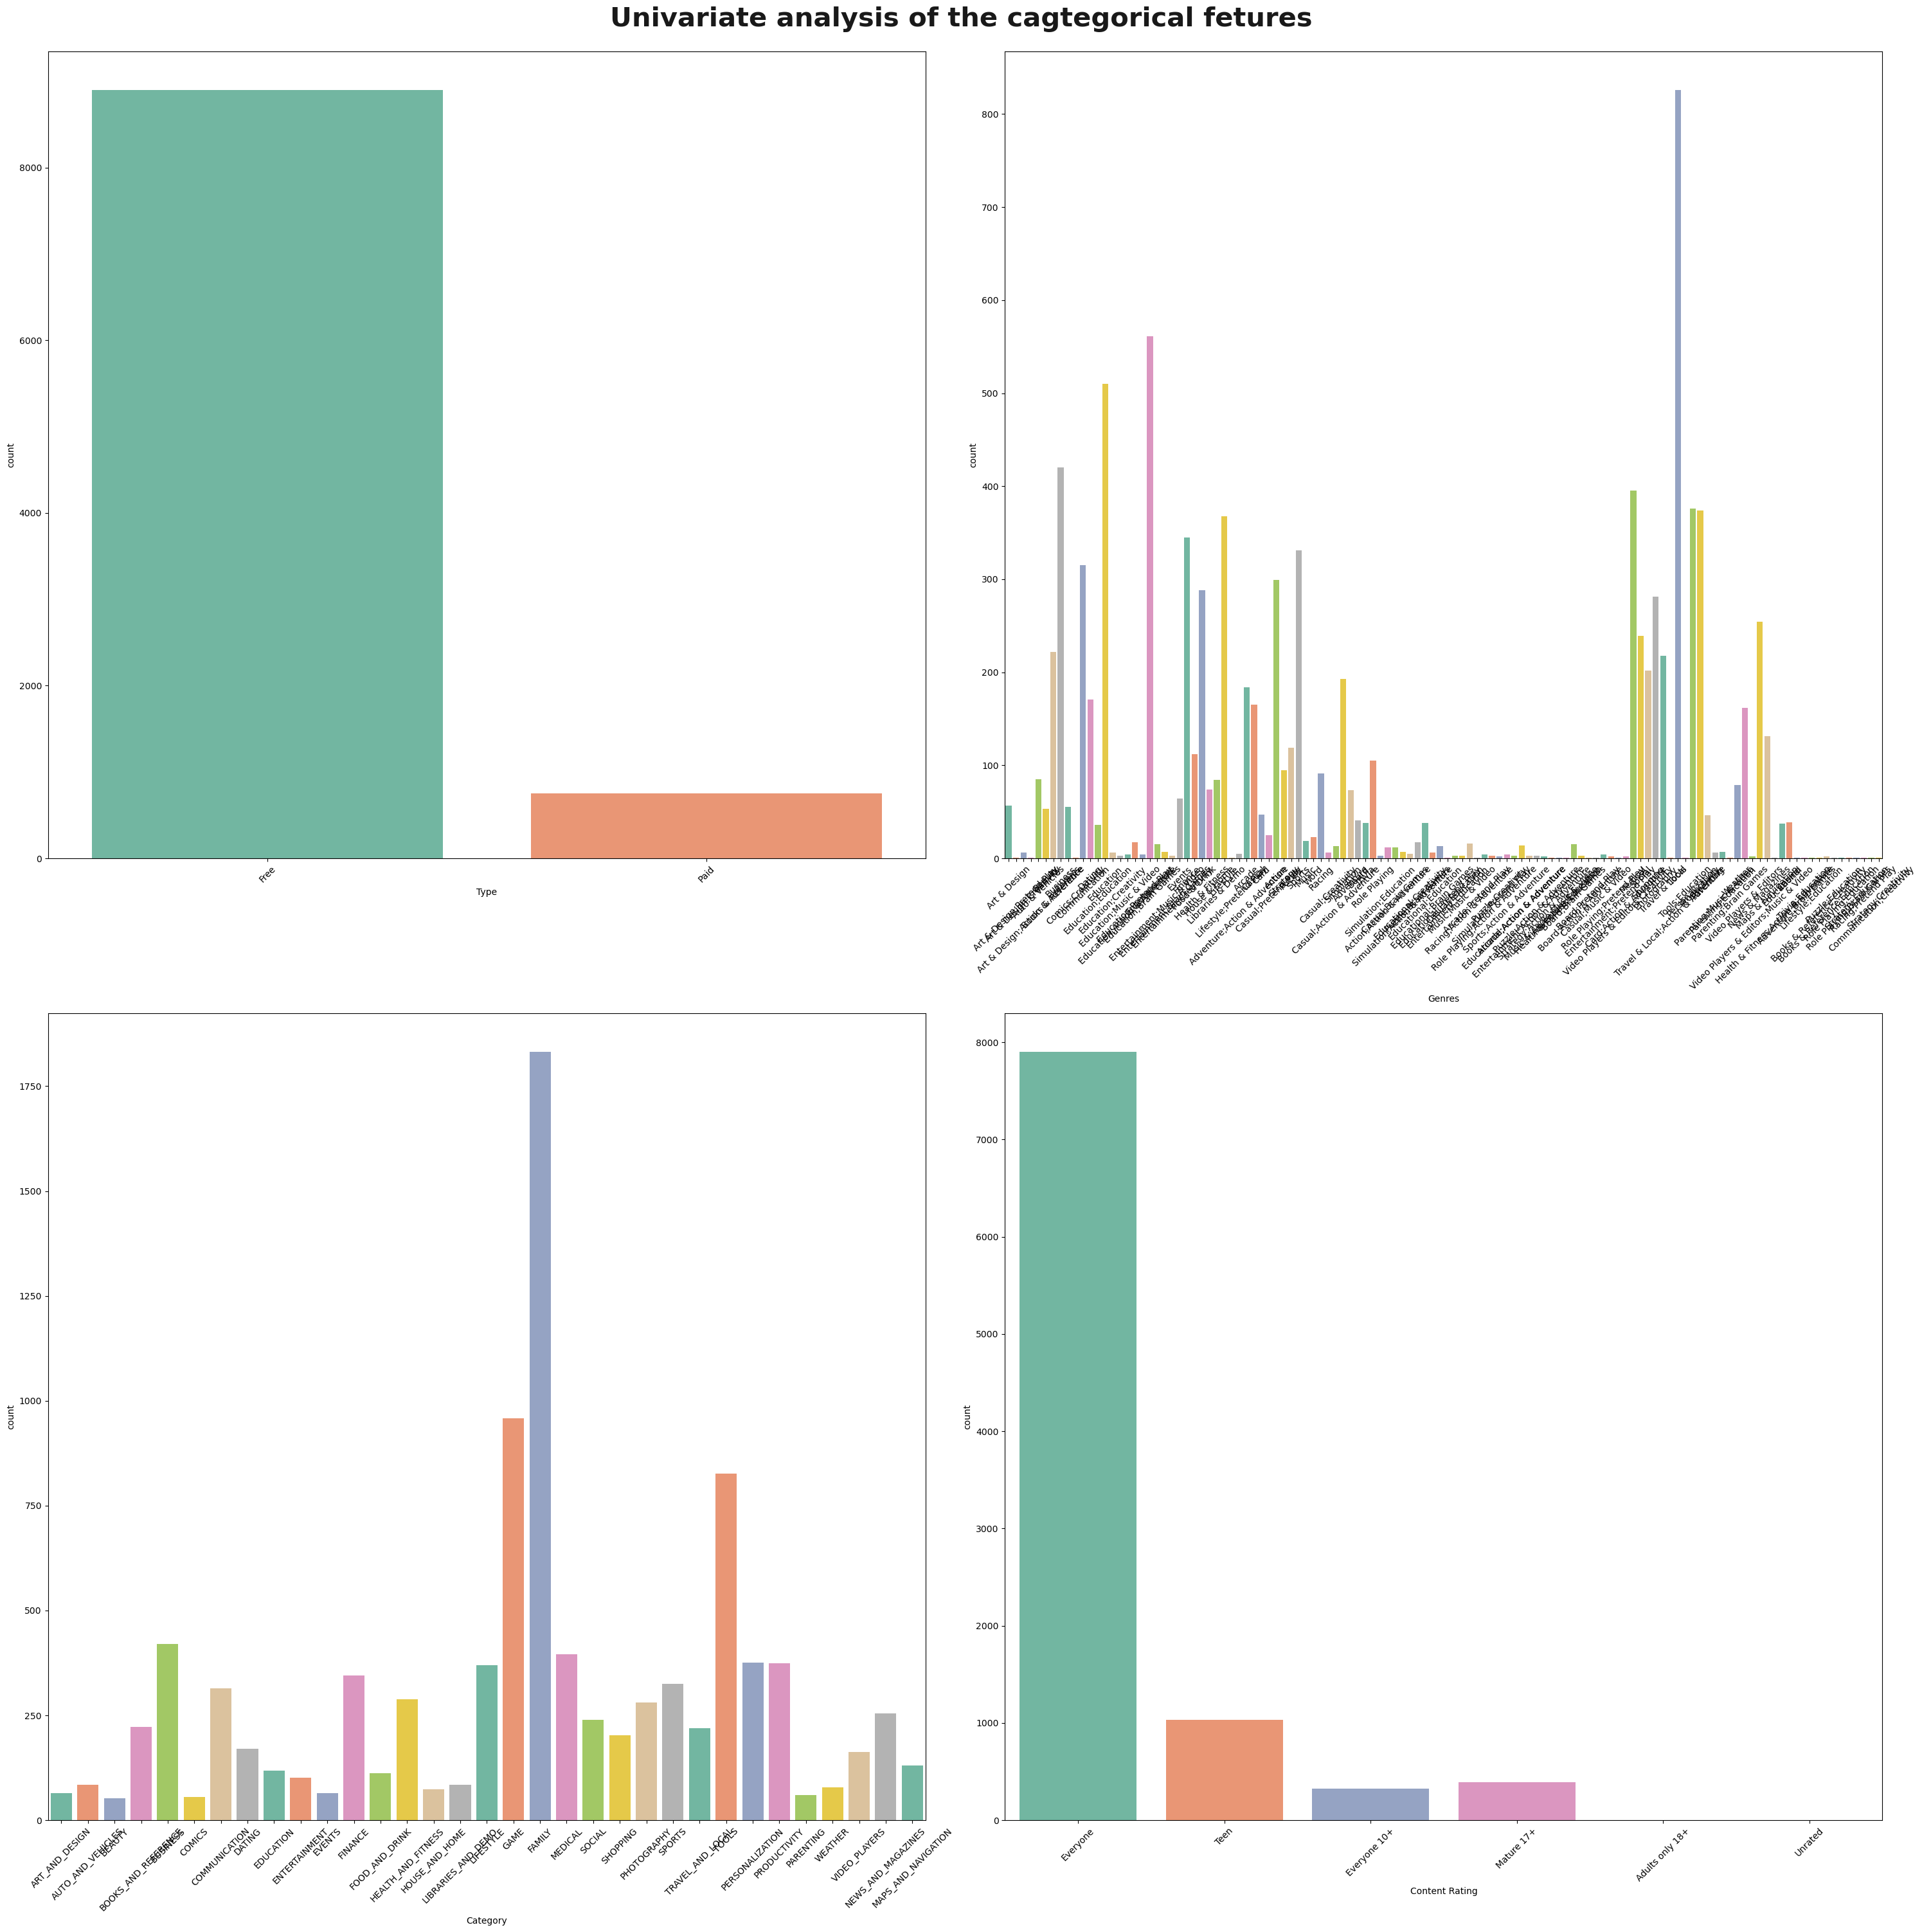

In [251]:
# count of categorical columns

# countplot for categorical data 

plt.figure(figsize=(30,30))

plt.suptitle("Univariate analysis of the cagtegorical fetures", fontsize= 30,fontweight= 'bold',alpha=0.9,y=1.)

category = ['Type','Genres','Category','Content Rating']

for i in range(0,len(category)):
    plt.subplot(2,2, i+1)
    sns.countplot(x = data[category[i]], palette='Set2')
    plt.xlabel(category[i])
    plt.xticks(rotation = 45)
    plt.tight_layout()



Text(0.5, 0, 'Genres')

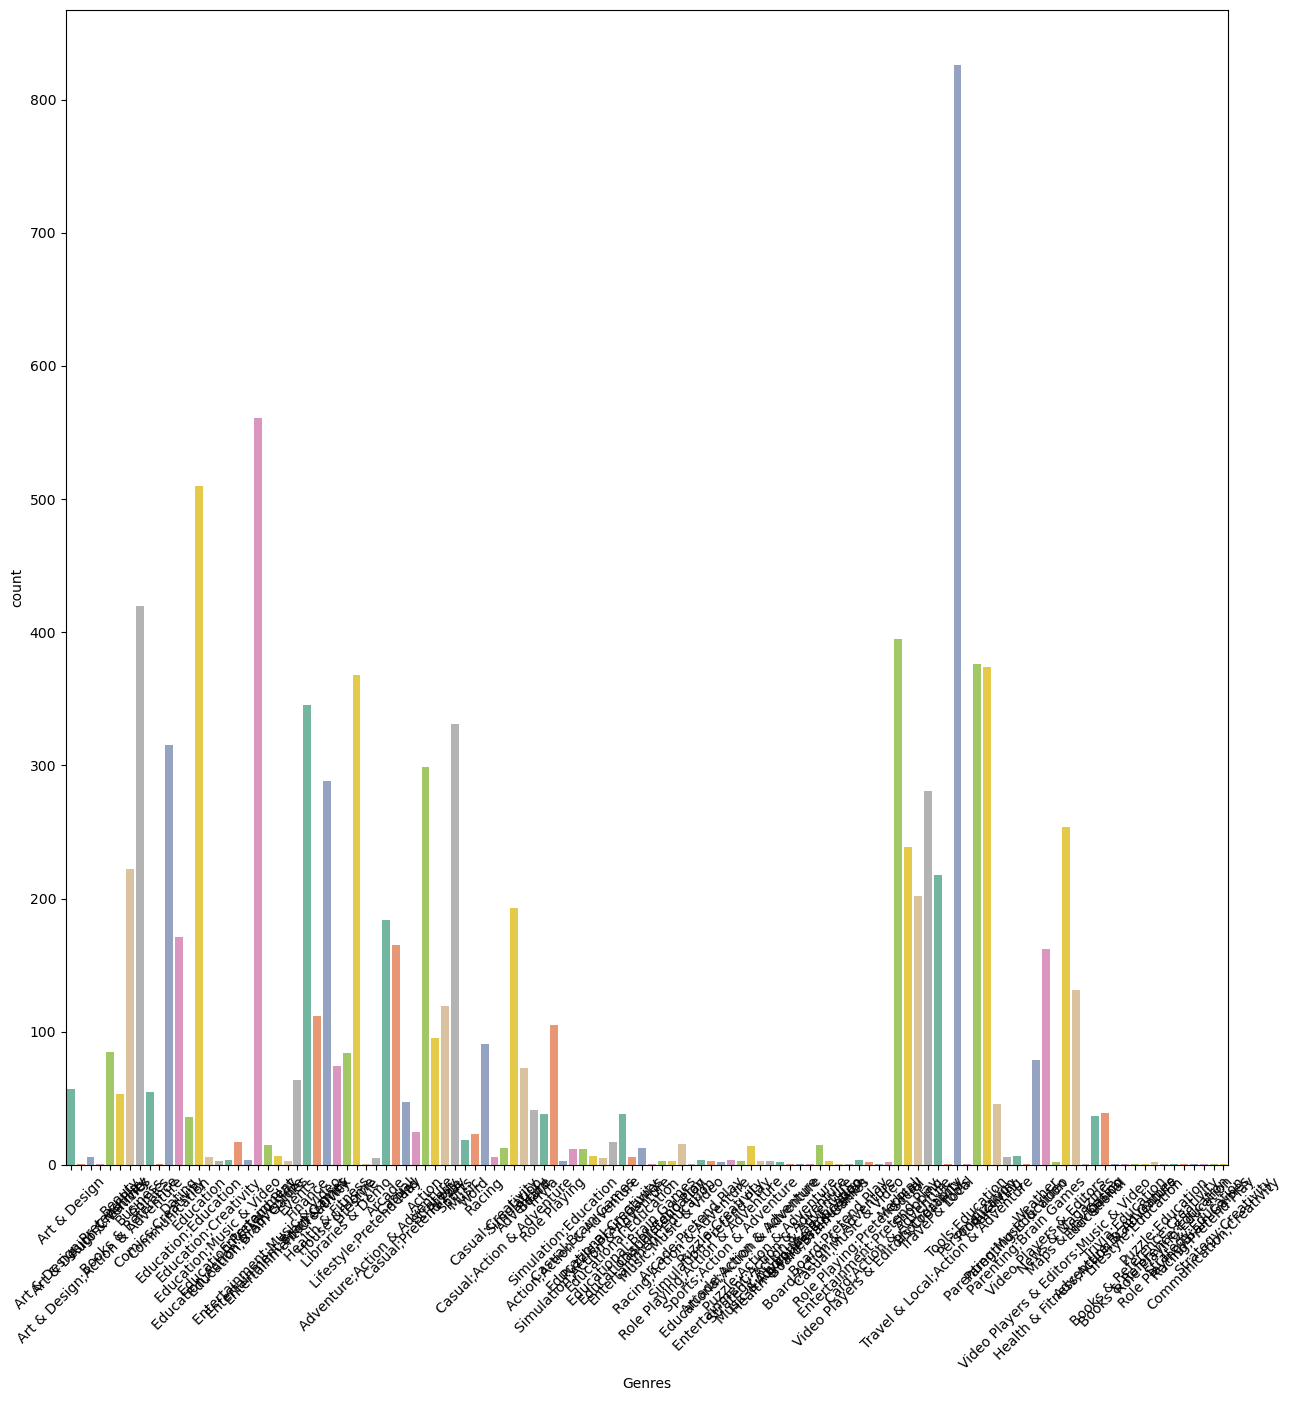

In [252]:
plt.figure(figsize =(15,15))


sns.countplot(x =data['Genres'],palette='Set2')
plt.xticks(rotation = 45)
plt.xlabel("Genres")

<Axes: ylabel='count'>

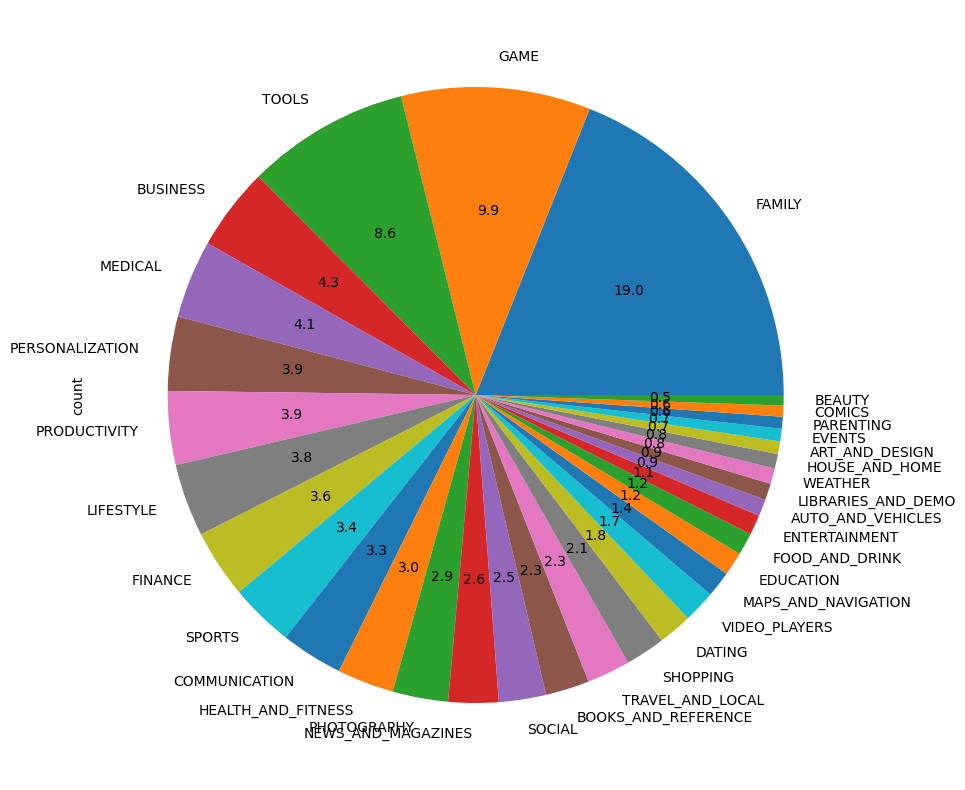

In [253]:
data["Category"].value_counts().plot.pie(figsize= (20,10),autopct= '%1.1f',y=data['Category'])

- top 3 app category are
1. family
2. Game
3. Tools

In [254]:
category = pd.DataFrame(data.Category.value_counts())
category.rename(columns= {'Category' : 'Count'},inplace= True)

In [255]:
category

,count
Category,
FAMILY,1832
GAME,959
TOOLS,827
BUSINESS,420
MEDICAL,395
PERSONALIZATION,376
PRODUCTIVITY,374
LIFESTYLE,369
FINANCE,345


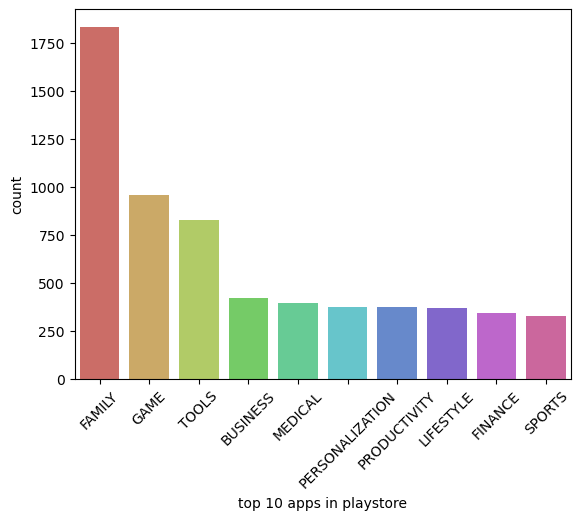

In [256]:
sns.barplot(x=category.index[:10], y = 'count', data = category[0:10], palette = 'hls')

plt.xlabel('top 10 apps in playstore')
plt.xticks(rotation = 45)

plt.show()

In [257]:
data

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Current Ver,Android Ver,Size(k),day,month,year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,1.0.0,4.0.3 and up,19000.0,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2.0.0,4.0.3 and up,14000.0,15,1,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,1.2.4,4.0.3 and up,8.7,1,8,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000,Free,0.0,Teen,Art & Design,Varies with device,4.2 and up,25000.0,8,6,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,1.1,4.4 and up,2.8,20,6,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10835,Sya9a Maroc - FR,FAMILY,4.5,38,53000.0,5000,Free,0.0,Everyone,Education,1.48,4.1 and up,53000.0,25,7,2017
10836,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6,100,Free,0.0,Everyone,Education,1.0,4.1 and up,3.6,6,7,2018
10837,Parkinson Exercices FR,MEDICAL,NaN,3,9.5,1000,Free,0.0,Everyone,Medical,1.0,2.2 and up,9.5,20,1,2017
10838,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,NaN,1000,Free,0.0,Mature 17+,Books & Reference,Varies with device,Varies with device,NaN,19,1,2015


In [ ]:
# 1. which category has largest number of installations

data.groupby('Category')['Installs'].sum().idxmax()


'GAME'

In [287]:
data.groupby('Category')['Installs'].sum().sort_values(ascending=False)
# data.groupby('Category')['Installs'].sum().sort_values(ascending=False)[:10]


Category
GAME                   13878924415
COMMUNICATION          11038276251
TOOLS                   8001771915
PRODUCTIVITY            5793091369
SOCIAL                  5487867902
PHOTOGRAPHY             4649147655
FAMILY                  4427941505
VIDEO_PLAYERS           3926902720
TRAVEL_AND_LOCAL        2894887146
NEWS_AND_MAGAZINES      2369217760
ENTERTAINMENT           2113660000
BOOKS_AND_REFERENCE     1665969576
PERSONALIZATION         1532494782
SHOPPING                1400348785
HEALTH_AND_FITNESS      1144022512
SPORTS                  1096474498
BUSINESS                 697164865
LIFESTYLE                503823539
MAPS_AND_NAVIGATION      503281890
FINANCE                  455348734
WEATHER                  361100520
EDUCATION                352952000
FOOD_AND_DRINK           211798751
DATING                   140926107
ART_AND_DESIGN           114338100
HOUSE_AND_HOME            97212461
AUTO_AND_VEHICLES         53130211
LIBRARIES_AND_DEMO        52995910
COMICS     

In [289]:
data['Category'].value_counts()

Category
FAMILY                 1832
GAME                    959
TOOLS                   827
BUSINESS                420
MEDICAL                 395
PERSONALIZATION         376
PRODUCTIVITY            374
LIFESTYLE               369
FINANCE                 345
SPORTS                  325
COMMUNICATION           315
HEALTH_AND_FITNESS      288
PHOTOGRAPHY             281
NEWS_AND_MAGAZINES      254
SOCIAL                  239
BOOKS_AND_REFERENCE     222
TRAVEL_AND_LOCAL        219
SHOPPING                202
DATING                  171
VIDEO_PLAYERS           163
MAPS_AND_NAVIGATION     131
EDUCATION               119
FOOD_AND_DRINK          112
ENTERTAINMENT           102
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       84
WEATHER                  79
HOUSE_AND_HOME           74
ART_AND_DESIGN           64
EVENTS                   64
PARENTING                60
COMICS                   56
BEAUTY                   53
Name: count, dtype: int64

In [297]:
# 2.what are the top 5 most installed apps in each category
for category, group in data.groupby('Category'):
    print(f"\nCategory: {category}")
    print(group['App'].tolist())


Category: ART_AND_DESIGN
['Photo Editor & Candy Camera & Grid & ScrapBook', 'Coloring book moana', 'U Launcher Lite – FREE Live Cool Themes, Hide Apps', 'Sketch - Draw & Paint', 'Pixel Draw - Number Art Coloring Book', 'Paper flowers instructions', 'Smoke Effect Photo Maker - Smoke Editor', 'Infinite Painter', 'Garden Coloring Book', 'Kids Paint Free - Drawing Fun', 'Text on Photo - Fonteee', 'Name Art Photo Editor - Focus n Filters', 'Tattoo Name On My Photo Editor', 'Mandala Coloring Book', '3D Color Pixel by Number - Sandbox Art Coloring', 'Learn To Draw Kawaii Characters', 'Photo Designer - Write your name with shapes', '350 Diy Room Decor Ideas', 'FlipaClip - Cartoon animation', 'ibis Paint X', 'Logo Maker - Small Business', "Boys Photo Editor - Six Pack & Men's Suit", 'Superheroes Wallpapers | 4K Backgrounds', 'Mcqueen Coloring pages', 'HD Mickey Minnie Wallpapers', 'Harley Quinn wallpapers HD', 'Colorfit - Drawing & Coloring', 'Animated Photo Editor', 'Pencil Sketch Drawing', '

In [320]:
top5 = data.groupby("Category",group_keys=False).apply(lambda c: c.nlargest(5,"Installs"))

top5

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Current Ver,Android Ver,Size(k),day,month,year,rank
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000,Free,0.0,Teen,Art & Design,Varies with device,4.2 and up,25000.0,8,6,2018,1.0
12,Tattoo Name On My Photo Editor,ART_AND_DESIGN,4.2,44829,20000.0,10000000,Free,0.0,Teen,Art & Design,3.8,4.1 and up,20000.0,2,4,2018,2.0
19,ibis Paint X,ART_AND_DESIGN,4.6,224399,31000.0,10000000,Free,0.0,Everyone,Art & Design,5.5.4,4.1 and up,31000.0,30,7,2018,3.0
42,Textgram - write on photos,ART_AND_DESIGN,4.4,295221,NaN,10000000,Free,0.0,Everyone,Art & Design,Varies with device,Varies with device,NaN,30,7,2018,4.0
45,"Canva: Poster, banner, card maker & graphic de...",ART_AND_DESIGN,4.7,174531,24000.0,10000000,Free,0.0,Everyone,Art & Design,1.6.1,4.1 and up,24000.0,31,7,2018,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3626,The Weather Channel: Rain Forecast & Storm Alerts,WEATHER,4.4,1558437,NaN,50000000,Free,0.0,Everyone,Weather,Varies with device,Varies with device,NaN,1,8,2018,1.0
3628,AccuWeather: Daily Forecast & Live Weather Rep...,WEATHER,4.4,2053404,NaN,50000000,Free,0.0,Everyone,Weather,Varies with device,Varies with device,NaN,6,8,2018,2.0
3649,"GO Weather - Widget, Theme, Wallpaper, Efficient",WEATHER,4.5,1422858,NaN,50000000,Free,0.0,Everyone,Weather,Varies with device,Varies with device,NaN,3,8,2018,3.0
4725,Weather & Clock Widget for Android,WEATHER,4.4,2371543,11000.0,50000000,Free,0.0,Everyone,Weather,5.9.4.0,4.0.3 and up,11000.0,4,6,2018,4.0


In [319]:
top5[[ 'App', 'Installs']].head(20)

App  \
Category                                                                      
ART_AND_DESIGN      3                                 Sketch - Draw & Paint   
                    12                       Tattoo Name On My Photo Editor   
                    19                                         ibis Paint X   
                    42                           Textgram - write on photos   
                    45    Canva: Poster, banner, card maker & graphic de...   
AUTO_AND_VEHICLES   72        Android Auto - Maps, Media, Messaging & Voice   
                    8289                      AutoScout24 - used car finder   
                    67                                   Ulysse Speedometer   
                    69                          Used cars for sale - Trovit   
                    70    Fines of the State Traffic Safety Inspectorate...   
BEAUTY              117                       Beauty Camera - Selfie Camera   
                    7021                       Best Hairstyles step by step   
                    99                       ipsy: Makeup, Beauty, and Tips   
                    102                          Mirror - Zoom & Exposure -   
                    105                                  Filters for Selfie   
BOOKS_AND_REFERENCE 152                                   Google Play Books   
                    139                                Wattpad 📖 Free Books   
                    143                                       Amazon Kindle   
                    3941                                              Bible   
                    5651                            Audiobooks from Audible   

                            Installs  
Category                              
ART_AND_DESIGN      3       50000000  
                    12      10000000  
                    19      10000000  
                    42      10000000  
                    45      10000000  
AUTO_AND_VEHICLES   72      10000000  
                    8289    10000000  
                    67       5000000  
                    69       5000000  
                    70       5000000  
BEAUTY              117     10000000  
                    7021     5000000  
                    99       1000000  
                    102      1000000  
                    105      1000000  
BOOKS_AND_REFERENCE 152   1000000000  
                    139    100000000  
                    143    100000000  
                    3941   100000000  
                    5651   100000000

In [317]:
data['rank'] = data.groupby('Category')['Installs']\
.rank(method='first', ascending=False)

top5 = data[data['rank'] <= 5]

top5[['Category', 'App', 'Installs']]

,Category,App,Installs
3,ART_AND_DESIGN,Sketch - Draw & Paint,50000000
12,ART_AND_DESIGN,Tattoo Name On My Photo Editor,10000000
19,ART_AND_DESIGN,ibis Paint X,10000000
42,ART_AND_DESIGN,Textgram - write on photos,10000000
45,ART_AND_DESIGN,"Canva: Poster, banner, card maker & graphic de...",10000000
...,...,...,...
8257,COMICS,Comics,5000000
8289,AUTO_AND_VEHICLES,AutoScout24 - used car finder,10000000
8445,SPORTS,FIFA Soccer,100000000
10253,BUSINESS,File Commander - File Manager/Explorer,100000000


In [260]:
# 3. how many apps are there on google play which get 5 ratings
star = [app for app in data.Rating if app == 5.0]
len(star)

271

In [263]:
len(data[data.Rating == 5.0])

271